# Inside the network

### How a neural network reads a light curve — and why we almost didn't need one

**ZTF Summer School.** No prior experience with neural networks assumed.

In the other notebooks you built FLARE: hand-crafted physics features feeding
gradient-boosted trees. It works very well. But hand-crafting features feels like
cheating — shouldn't a modern model read the *raw* light curve and figure out the
physics by itself?

We spent months on exactly that question. This notebook replays the journey in
miniature. You will:

1. build a **single neuron** in numpy and watch it learn,
2. see why an ordinary network **cannot** read a light curve,
3. build — from scratch, in ~40 lines — the recurrent architecture that can,
4. meet the **three properties of ZTF data** that dictated every design choice,
5. feed the physics features *into* the network and watch what happens,
6. read the full-scale measurements and decide, like we had to, what wins.

Every model here trains on a CPU in minutes. The full-scale versions differ only
in size and training time, not in kind.

In [1]:
import os, sys, time, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

sys.path.insert(0, "../..")
from flare import BROAD_CLASSES
from flare import data as D
from flare.taxonomy import ID2BROAD_ID

DATA_DIR = os.environ.get("FLARE_DATA",
    "/work/hdd/bcrv/ffontinelenunes/data/AppleCider/photo_events")
D.DATA_DIR = __import__("pathlib").Path(DATA_DIR)

CLASS_COLOR = {"SNI": "#0072B2", "SNII": "#E69F00", "CV": "#009E73",
               "AGN": "#CC79A7", "TDE": "#D55E00"}
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
torch.manual_seed(0); np.random.seed(0)
DEVICE = "cpu"           # everything below is CPU-sized on purpose
print("Setup OK — torch", torch.__version__)

Setup OK — torch 2.10.0+cu128


---
## 1. The raw material, and why it is awkward

Look closely at three real objects — not at the physics this time, but at the
*shape of the data itself*.

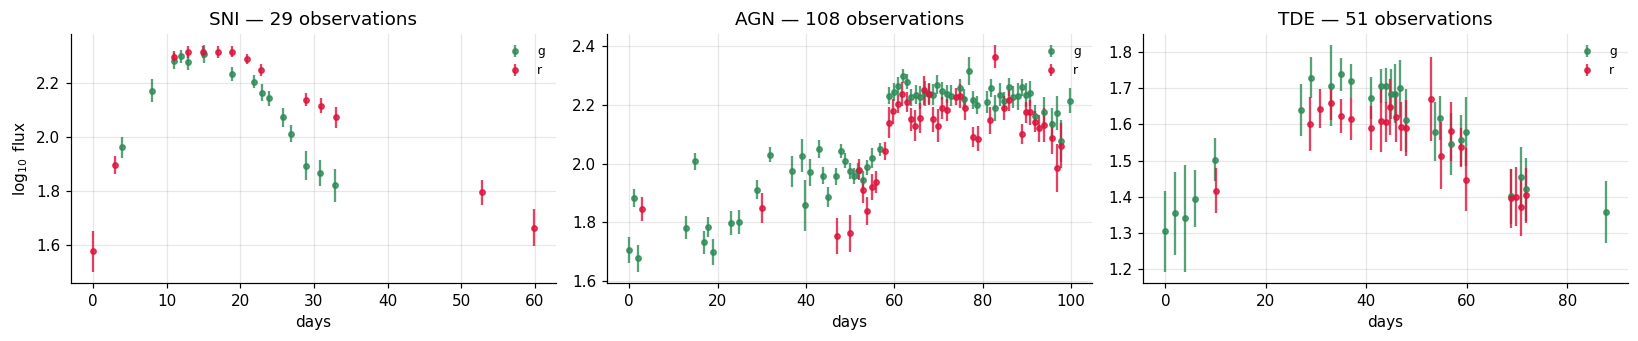

observations per object: min=1, median=72, max=2404


In [2]:
manifest = D.load_manifest("train")
manifest["broad"] = manifest["label"].map(lambda x: BROAD_CLASSES[ID2BROAD_ID[int(x)]])

picks = []
for cls, n in [("SNI", 0), ("AGN", 2), ("TDE", 0)]:
    picks.append(manifest[manifest.broad == cls].sort_values("n_events").iloc[len(manifest[manifest.broad==cls])//2 + n])

fig, axes = plt.subplots(1, 3, figsize=(15, 3.2))
for ax, row in zip(axes, picks):
    arr = D.load_events(row.filepath)
    bands = D.reconstruct_bands(arr)
    for name, colr in [("g", "seagreen"), ("r", "crimson")]:
        if name in bands:
            ax.errorbar(bands[name].t, bands[name].logflux,
                        yerr=bands[name].logflux_err, fmt="o", ms=3.5,
                        color=colr, alpha=0.8, label=name)
    ax.set_title(f"{row.broad} — {len(arr)} observations")
    ax.set_xlabel("days"); ax.legend(frameon=False, fontsize=8)
axes[0].set_ylabel(r"$\log_{10}$ flux")
plt.tight_layout(); plt.show()

lens = manifest.n_events
print(f"observations per object: min={lens.min()}, median={int(lens.median())}, "
      f"max={lens.max()}")

Three properties jump out, and each one will force an architectural decision.
Keep this table — it is the skeleton of the whole notebook:

| # | Property of the data | Consequence for a model | Our answer (later) |
|---|---|---|---|
| **P1** | Every object has a **different number** of observations, at **irregular times** — gaps of days or weeks, then bursts | The input is not a fixed-size vector, and "position 7" means a different time for every object | give the model the **clock**: Δt is an input |
| **P2** | Observations from different **filters (g, r, i) interleave** in one stream | A brightness of 120 μJy means something different in g than in r | let the band **re-tune** the network (FiLM) |
| **P3** | The classifier needs **one answer per object**, whatever its length | Many vectors must become one, without a human deciding which nights matter | let the model **learn where to look** (attention pooling) |

The trees never faced these problems — the feature extractor absorbed all three
(it summarises any curve into the same 160 numbers). If we want a network to read
the raw curve, *we* have to solve them.

But first: what even is a neural network? Let's build the smallest one that
exists.

---
## 2. A single neuron, from nothing

A neuron is a straight line with an opinion. It computes

$$z = w_1 x_1 + w_2 x_2 + b, \qquad p = \sigma(z) = \frac{1}{1+e^{-z}}$$

— a weighted sum of its inputs, squashed to a probability. The numbers $w_1, w_2,
b$ are the **weights**: the neuron's only knowledge. **Learning** means nudging
them, over and over, in the direction that reduces the error. That's it. That
nudge — *gradient descent* — is the entire secret of deep learning; everything
else is scale.

Watch one learn to separate supernovae from AGN using two physics features you
already know: the mean $g-r$ colour and the amplitude of variability.

In [3]:
# two features, two classes — extracted in the why_flare_works notebook cache
# (falls back to a fresh extraction of a small sample if the cache is missing)
cache = __import__("pathlib").Path("../../artifacts/why_train.parquet")
if cache.exists():
    tab = pd.read_parquet(cache)
else:
    from flare.features import extract_object_features
    rows = []
    for _, r in manifest.groupby("broad").head(400).iterrows():
        try:
            f = extract_object_features(r.filepath); f["label"] = r.label
            rows.append(f)
        except Exception:
            pass
    tab = pd.DataFrame(rows)

yb = tab["label"].map(lambda x: ID2BROAD_ID[int(x)]).values
m = np.isin(yb, [0, 3])                            # SNI vs AGN
F = tab.loc[m, ["g_r_mean", "g_amplitude"]].to_numpy(dtype=float)
t = (yb[m] == 0).astype(float)                     # 1 = SNI, 0 = AGN
ok = np.isfinite(F).all(1); F, t = F[ok], t[ok]
F = (F - F.mean(0)) / F.std(0)                     # standardize
print(f"{len(t)} objects, {int(t.sum())} SNI / {int((1-t).sum())} AGN")

7361 objects, 3928 SNI / 3433 AGN


final loss 0.344,  accuracy 86.1%,  w = [0.51 2.9 ], b = +0.83


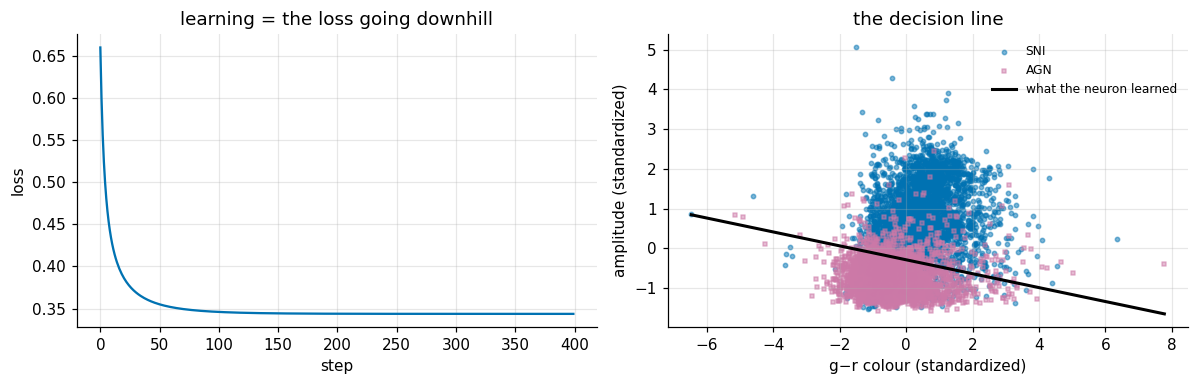

In [4]:
# --- the entire learning algorithm, no libraries ---
rng = np.random.default_rng(1)
w, b = rng.normal(0, .1, 2), 0.0
lr, losses = 0.5, []
for step in range(400):
    z = F @ w + b
    p = 1 / (1 + np.exp(-z))                       # prediction
    losses.append(-np.mean(t*np.log(p+1e-9) + (1-t)*np.log(1-p+1e-9)))
    grad_z = (p - t) / len(t)                      # how wrong, per object
    w -= lr * (F.T @ grad_z)                       # nudge the weights...
    b -= lr * grad_z.sum()                         # ...and the bias
acc = ((p > .5) == t).mean()
print(f"final loss {losses[-1]:.3f},  accuracy {acc:.1%},  w = {np.round(w,2)}, b = {b:+.2f}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))
a1.plot(losses, color="#0072B2"); a1.set_xlabel("step"); a1.set_ylabel("loss")
a1.set_title("learning = the loss going downhill")
for lab, mk, colr in [(1, "o", CLASS_COLOR["SNI"]), (0, "s", CLASS_COLOR["AGN"])]:
    sel = t == lab
    a2.scatter(F[sel, 0], F[sel, 1], s=8, marker=mk, alpha=.5, color=colr,
               label="SNI" if lab else "AGN")
xs = np.linspace(F[:, 0].min(), F[:, 0].max(), 2)
a2.plot(xs, -(w[0]*xs + b)/w[1], "k-", lw=2, label="what the neuron learned")
a2.set_xlabel("g−r colour (standardized)"); a2.set_ylabel("amplitude (standardized)")
a2.legend(frameon=False, fontsize=8); a2.set_title("the decision line")
plt.tight_layout(); plt.show()

Twelve lines of numpy: predict, measure the error, push every weight slightly
against its share of the blame, repeat. The line settles exactly where an
astronomer would draw it — supernovae are the redder-when-averaged, high-amplitude
cloud.

A **neural network** is this, three ideas deeper:

- **many neurons in parallel** = a *layer* (many lines drawn at once);
- **layers stacked**, each reading the previous one's output = curves instead of
  lines, then curves of curves;
- the same nudge-the-blame rule, applied through the whole stack automatically
  (*backpropagation* — a bookkeeping algorithm, not a new idea).

You already met such a stack in `why_flare_works.ipynb`: the scikit-learn MLP,
which took the 160 features and did fine. So the interesting question is not
"can a network classify" — it is whether one can read the **raw curve**, where
the input is not a tidy fixed-size vector.

---
## 3. Why the ordinary network cannot read a light curve

An MLP has a fixed number of input wires. Our objects have 8 observations, or
147, or 300 (**P1**). Three standard escapes, all bad here:

- **Pad to the longest** and flatten → wire #212 must mean "the 106th
  observation", but at *what time*? For one object that is day 30, for another
  day 3. The network would have to learn every alignment separately — with 9,000
  objects, hopeless.
- **Resample onto a regular grid** → you must invent flux in week-long gaps.
  With sparse, noisy curves, most of your input becomes interpolation artefact.
- **Summary statistics** → that is *exactly* the feature extractor we already
  have. No new information.

The escape that works is different in kind: **read the curve one observation at a
time, in order, carrying a memory.** That is a *recurrent* network. Each step it
combines "what I just saw" with "what I remember so far" into a new memory; the
memory after the last observation is a summary of the whole curve — built by the
model, not by us.

The specific recurrent cell we use is the **GRU** (gated recurrent unit). Its
trick is two learned *gates* — small neurons that output 0-to-1 — deciding, at
every step, **how much of the old memory to keep** and **how much of the new
observation to write**. A quiet AGN night barely touches the memory; the first
night of a rising supernova overwrites a lot of it. The model learns *what is
worth remembering* — which is, if you think about it, what a human classifier
does when scanning a light curve.

---
## 4. The architecture, from scratch

Here is the entire model — a miniature of FLARE's real neural companion. Read it
top to bottom against P1–P3; every line answers one of them.

Three design decisions to notice:

- **P1 → the clock is an input.** We never resample. Each observation carries
  its own $\log(1{+}\Delta t)$ since the previous one and since the start. The
  network *reads time* like any other measurement — irregularity stops being a
  problem and becomes information (a 40-day gap in an AGN is business as usual;
  in a young SN it hides the whole story).
- **P2 → FiLM: the filter re-tunes the network.** Instead of just appending a
  one-hot band flag, the band produces a per-unit scale $\gamma$ and shift
  $\beta$ applied to the embedded observation: $h \mapsto (1{+}\gamma)\odot h +
  \beta$. The *same* neurons process g and r nights, but the band twists their
  gains — like one radio receiver retuned per station, rather than three
  separate radios (which would each see a third of the data).
- **P3 → attention pooling: learned importance.** After the GRU, every night has
  a memory-vector. A tiny neuron scores each night, softmax turns scores into
  weights summing to 1, and the object's summary is the weighted average. The
  model literally learns *which nights matter* — and we can plot those weights
  and see what it looked at.

In [5]:
class MiniFilmGRU(nn.Module):
    '''FiLM-GRU + attention pooling (+ optional physics-feature block).'''

    def __init__(self, d=48, n_layers=2, n_classes=5,
                 use_film=True, n_feats=0):
        super().__init__()
        self.use_film = use_film
        self.embed = nn.Linear(4, d)          # Δt_start, Δt_prev, flux, err  (P1)
        self.film  = nn.Linear(3, 2 * d)      # band one-hot -> per-unit γ, β (P2)
        self.gru   = nn.GRU(d, d, num_layers=n_layers, batch_first=True)
        self.score = nn.Linear(d, 1)          # attention: one score per night (P3)
        self.feat_proj = (nn.Sequential(nn.LayerNorm(n_feats),
                                        nn.Linear(n_feats, d), nn.GELU())
                          if n_feats else None)
        self.head  = nn.Linear(d * (2 if n_feats else 1), n_classes)

    def forward(self, x, band, pad, feats=None):
        h = self.embed(x)                              # (B, L, d)
        if self.use_film:
            gamma, beta = self.film(band).chunk(2, -1)
            h = h * (1 + gamma) + beta                 # the band re-tunes h (P2)
        h, _ = self.gru(h)                             # memory over time    (P1)
        a = self.score(h).squeeze(-1)                  # (B, L) night scores
        a = a.masked_fill(pad, -1e9).softmax(-1)       # padded nights: weight 0
        z = (h * a.unsqueeze(-1)).sum(1)               # learned summary     (P3)
        if self.feat_proj is not None:                 # physics block (see §6)
            z = torch.cat([z, self.feat_proj(feats)], -1)
        return self.head(z), a

n_par = sum(p.numel() for p in MiniFilmGRU().parameters())
print(f"MiniFilmGRU: {n_par:,} parameters (the full-scale model: ~655,000)")

MiniFilmGRU: 29,142 parameters (the full-scale model: ~655,000)


That is the whole thing. The full-scale version differs in width (96 vs 48
units), a stack of temporal-convolution layers that pre-digest the sequence at
several time scales, cosine-similarity classification, heavy augmentation, and a
self-supervised warm-up — engineering, not new concepts.

Now let's feed it. The collate step below does the padding (P1's bookkeeping):
short objects are padded with zeros, and a `pad` mask tells the attention to
ignore those slots.

In [6]:
CAP = 120     # cap sequence length: keeps CPU training fast

def build_tensors(df, mu=None, sd=None):
    xs, bands, ys, lens = [], [], [], []
    for _, row in df.iterrows():
        arr = D.load_events(row.filepath)[:CAP]
        dt      = np.log1p(arr[:, D.COL["dt"]])
        dtp     = np.log1p(arr[:, D.COL["dt_prev"]])
        lf      = arr[:, D.COL["logflux"]]
        lfe     = arr[:, D.COL["logflux_err"]]
        b       = arr[:, D.COL["band_id"]].astype(int)
        xs.append(np.stack([dt, dtp, lf, lfe], 1).astype(np.float32))
        bands.append(np.eye(3, dtype=np.float32)[np.clip(b, 0, 2)])
        ys.append(ID2BROAD_ID[int(row.label)]); lens.append(len(arr))
    L = max(lens)
    X  = np.zeros((len(xs), L, 4), np.float32)
    Bd = np.zeros((len(xs), L, 3), np.float32)
    P  = np.ones((len(xs), L), bool)
    for i, (x, b, n) in enumerate(zip(xs, bands, lens)):
        X[i, :n], Bd[i, :n], P[i, :n] = x, b, False
    if mu is None:                                   # flux stats from TRAIN only
        mu = X[..., 2][~P].mean(), X[..., 3][~P].mean()
        sd = X[..., 2][~P].std(),  X[..., 3][~P].std()
    X[..., 2] = np.where(P, 0, (X[..., 2] - mu[0]) / sd[0])
    X[..., 3] = np.where(P, 0, (X[..., 3] - mu[1]) / sd[1])
    T = lambda a: torch.tensor(a)
    return (T(X), T(Bd), T(P), T(np.array(ys))), (mu, sd)

mf_all = {s: D.filter_manifest_quality(D.load_manifest(s))[0] for s in ["train", "val", "test"]}
rng = np.random.default_rng(0)
mf_tr = (mf_all["train"]
         .assign(broad=lambda d: d.label.map(lambda x: ID2BROAD_ID[int(x)]))
         .groupby("broad", group_keys=False)
         .apply(lambda g: g.sample(min(len(g), 700), random_state=0)))
print("training subset:", len(mf_tr), "objects (CPU-friendly; all TDEs kept)")

t0 = time.time()
train_T, stats = build_tensors(mf_tr)
val_T,  _ = build_tensors(mf_all["val"],  stats[0], stats[1])
test_T, _ = build_tensors(mf_all["test"], stats[0], stats[1])
print(f"tensors built in {time.time()-t0:.0f}s — train {tuple(train_T[0].shape)}")

training subset: 2493 objects (CPU-friendly; all TDEs kept)


tensors built in 87s — train (2493, 120, 4)


Training is the neuron's loop from §2, wearing industrial clothes: mini-batches,
the Adam optimiser (gradient descent with per-weight step sizes), and a
class-weighted loss so 47 TDEs are not drowned by 4,000 SNI.

In [7]:
def run_model(model, train_T, val_T, epochs=10, bs=128, lr=3e-3, feats=None,
              feats_val=None, quiet=False):
    X, Bd, P, y = train_T
    counts = torch.bincount(y, minlength=5).float()
    wclass = (len(y) / (5 * counts)).clamp(max=30)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = nn.CrossEntropyLoss(weight=wclass)
    for ep in range(1, epochs + 1):
        model.train(); perm = torch.randperm(len(y))
        tot = 0.0
        for i in range(0, len(y), bs):
            ix = perm[i:i + bs]
            f = feats[ix] if feats is not None else None
            logits, _ = model(X[ix], Bd[ix], P[ix], f)
            loss = lossf(logits, y[ix])
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item() * len(ix)
        if not quiet and (ep % 2 == 0 or ep == 1):
            model.eval()
            with torch.no_grad():
                lv, _ = model(*val_T[:3], feats_val)
                acc = (lv.argmax(1) == val_T[3]).float().mean()
            print(f"  epoch {ep:2d}: train loss {tot/len(y):.3f}   val acc {acc:.3f}")
    return model

def evaluate(model, T, feats=None):
    model.eval()
    with torch.no_grad():
        logits, attn = model(*T[:3], feats)
        p = logits.softmax(-1).numpy()
    y = T[3].numpy(); pred = p.argmax(1)
    from sklearn.metrics import f1_score, balanced_accuracy_score
    return {"acc": (pred == y).mean(),
            "balacc": balanced_accuracy_score(y, pred),
            "macroF1": f1_score(y, pred, average="macro"),
            "TDE found": f"{int(((pred==4)&(y==4)).sum())}/{int((y==4).sum())}"}, attn

In [8]:
torch.manual_seed(0)
plain = MiniFilmGRU(use_film=False)
print("GRU without band information (P2 switched off):")
run_model(plain, train_T, val_T, epochs=10)

torch.manual_seed(0)
film = MiniFilmGRU(use_film=True)
print("\nFiLM-GRU (the band re-tunes the network):")
run_model(film, train_T, val_T, epochs=10)

m_plain, _   = evaluate(plain, test_T)
m_film, attn = evaluate(film, test_T)
res = pd.DataFrame([m_plain, m_film],
                   index=["GRU, band-blind", "FiLM-GRU"])
print("\nTest set:"); print(res.to_string())

GRU without band information (P2 switched off):


  epoch  1: train loss 1.414   val acc 0.485


  epoch  2: train loss 1.194   val acc 0.613


  epoch  4: train loss 1.012   val acc 0.585


  epoch  6: train loss 0.868   val acc 0.682


...

  epoch  4: train loss 0.954   val acc 0.643


  epoch  6: train loss 0.733   val acc 0.710


  epoch  8: train loss 0.579   val acc 0.736


  epoch 10: train loss 0.525   val acc 0.663



Test set:
                      acc    balacc   macroF1 TDE found
GRU, band-blind  0.680647  0.700277  0.533107       6/9
FiLM-GRU         0.694290  0.748265  0.561980       7/9


Same data, same size, same training — the only difference is whether the network
knows *which filter* each observation came from. The gap is the empirical content
of **P2**: colour information lives in the g/r interleaving, and a band-blind
reader cannot see it.

And because of **P3** we can do something no tree can: ask the model *where it
looked*.

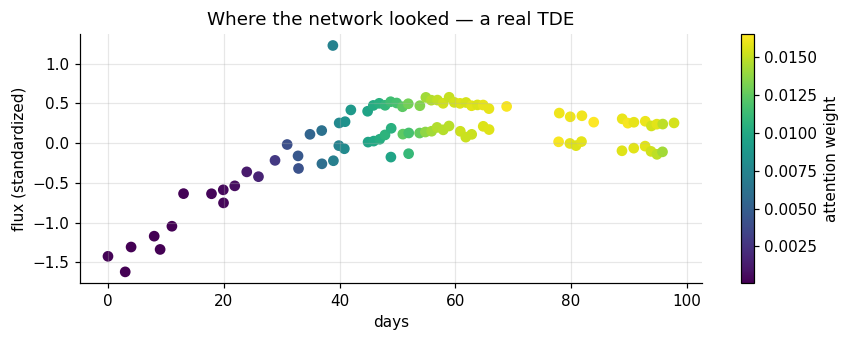

Bright points = nights the model weighted most when summarising this object.


In [9]:
X, Bd, P, y = test_T
tde_ix = np.where(y.numpy() == 4)[0]
i = int(tde_ix[0]) if len(tde_ix) else 0
n = int((~P[i]).sum())
t_days = np.expm1(X[i, :n, 0].numpy())
w = attn[i, :n].numpy()

fig, ax = plt.subplots(figsize=(8, 3.2))
sc = ax.scatter(t_days, X[i, :n, 2].numpy(), c=w, cmap="viridis", s=36)
plt.colorbar(sc, label="attention weight")
ax.set_xlabel("days"); ax.set_ylabel("flux (standardized)")
ax.set_title(f"Where the network looked — a real {BROAD_CLASSES[int(y[i])]}")
plt.tight_layout(); plt.show()
print("Bright points = nights the model weighted most when summarising this object.")

---
## 5. The twist: give the network the features too

So the network *can* read raw curves. But you already know from
`why_flare_works.ipynb` that 160 physics features + trees beat every learner we
threw at them. This raises an uncomfortable question we eventually had to face:

> If the physics features carry most of the signal, why make the network
> re-derive them from scratch — with 9,000 examples — when a century of
> astronomy will hand them over for free?

So we stopped choosing between the two. The fusion model reads **both**: the raw
sequence through the FiLM-GRU, *and* the 160 features through a small side block
(`feat_proj` in the class above — it was there all along), concatenated right
before the classifier. The network keeps what the features cannot see (fine
temporal structure), the features anchor what small data cannot teach.

In [10]:
# 160 physics features for the same objects (median-impute + robust scale).
# Cached by why_flare_works.ipynb; row order there = quality-filtered manifest
# order, which lets us key rows by obj_id below.
cache = __import__("pathlib").Path("../../artifacts")
tabs = {s: pd.read_parquet(cache / f"why_{s}.parquet")
        for s in ["train", "val", "test"]}
FEATC = sorted(c for c in tabs["train"].columns if c != "label")

def feats_for(mf, split, med, iqr):
    t = tabs[split]
    full_mf = mf_all[split].reset_index(drop=True)
    if len(t) != len(full_mf):
        raise RuntimeError("cache/manifest mismatch — rerun why_flare_works first")
    t = t.set_index(full_mf.obj_id)[FEATC]
    M = t.loc[mf.obj_id].to_numpy(dtype=np.float64)
    M = np.where(np.isfinite(M), M, med)
    return torch.tensor(np.clip((M - med) / iqr, -10, 10), dtype=torch.float32)

Mtr = tabs["train"][FEATC].to_numpy(dtype=np.float64)
MED = np.nanmedian(Mtr, 0)
IQR = np.nanpercentile(Mtr, 75, 0) - np.nanpercentile(Mtr, 25, 0)
IQR = np.where(IQR < 1e-9, 1, IQR)

f_tr  = feats_for(mf_tr, "train", MED, IQR)
f_val = feats_for(mf_all["val"], "val", MED, IQR)
f_te  = feats_for(mf_all["test"], "test", MED, IQR)
print("feature blocks:", tuple(f_tr.shape), tuple(f_val.shape), tuple(f_te.shape))

feature blocks: (2493, 160) (1991, 160) (1979, 160)


In [11]:
torch.manual_seed(0)
fusion = MiniFilmGRU(use_film=True, n_feats=len(FEATC))
print("FiLM-GRU + 160 physics features (fusion):")
run_model(fusion, train_T, val_T, epochs=10, feats=f_tr, feats_val=f_val)

m_fus, _ = evaluate(fusion, test_T, f_te)
res = pd.DataFrame([m_plain, m_film, m_fus],
                   index=["GRU, band-blind", "FiLM-GRU", "FiLM-GRU + features"])
print("\nTest set:"); print(res.to_string())

FiLM-GRU + 160 physics features (fusion):


  epoch  1: train loss 1.088   val acc 0.832


  epoch  2: train loss 0.521   val acc 0.839


  epoch  4: train loss 0.319   val acc 0.860


  epoch  6: train loss 0.243   val acc 0.872


  epoch  8: train loss 0.193   val acc 0.885


  epoch 10: train loss 0.165   val acc 0.896



Test set:
                          acc    balacc   macroF1 TDE found
GRU, band-blind      0.680647  0.700277  0.533107       6/9
FiLM-GRU             0.694290  0.748265  0.561980       7/9
FiLM-GRU + features  0.903992  0.825107  0.734748       5/9


Even at toy scale the ordering is visible — and at full scale, with proper
training, it is dramatic. Which brings us to the measurements that actually
decided the architecture.

---
## 6. What we measured at full scale

You now know every concept in the real system. Here is the journey it went
through, compressed.

**Round 1 — the encoder tournament.** We built one training pipeline and swapped
nine sequence-reading architectures through it: our FiLM-GRU (+ temporal
convolutions), and the fashionable alternatives — Transformers in several
flavours, a state-space model (Mamba), an extended LSTM, MLP-mixer variants, a
Perceiver. Same data, same augmentation, same training loop, same test set.

| Encoder (same pipeline) | Macro F1 | Params |
|---|---|---|
| **FiLM-GRU + TCN** | **0.75** | **655K** |
| FiLM-GRU + mixture-of-experts | 0.71 | 2.3M |
| Perceiver | 0.68 | 1.8M |
| xLSTM | 0.67 | 1.2M |
| TSMixer | 0.65 | 2.5M |
| PatchTST (transformer) | 0.63 | 1.4M |
| iTransformer | 0.62 | 1.6M |
| Mamba | 0.56 | 2.0M |

The recurrent model won *with the fewest parameters*. This is the small-data
regime asserting itself (P0, if you like): attention-based models are
data-hungry — their flexibility is exactly what overfits 9,000 curves. The GRU's
rigid read-in-order bias is a *feature* here, not a limitation. **Architectures
are not better or worse; they are matched or mismatched to a data regime.**

**Round 2 — networks vs features+trees.** The tournament winner then faced the
FLARE baseline on equal terms (five-fold cross-validation, 13,153 objects):

| Model | Acc | Balanced acc | Macro F1 | Calibration (ECE) |
|---|---|---|---|---|
| features + trees (FLARE) | **0.949** | 0.839 | **0.855** | **0.010** |
| FiLM-GRU alone (raw curves) | 0.933 | 0.806 | 0.813 | 0.090 |

The network read raw data and *almost* caught the trees — a genuine achievement —
but it never passed them, and its probabilities were far less honest.

**Round 3 — fusion.** Feed the 160 features into the network (as in §5, plus one
crucial repair: the feature block was first given a 64-wide channel while the
sequence had 96 — widening it to 96, so physics enters on equal terms, was worth
several points). On the held-out test set of the original split:

| Model | Acc | Balanced acc | Macro F1 | TDE found |
|---|---|---|---|---|
| features + trees | **0.957** | 0.808 | 0.841 | 3/9 |
| fusion (GRU + features) | 0.954 | **0.850** | **0.864** | **5/9** |

That table looks like a breakthrough: the first network to lead the trees on
macro $F_1$ and balanced accuracy. **It is also a trap — and we let you walk into
it on purpose.** One split, 1,979 objects, *nine* TDEs: at that sample size a
point or two of macro $F_1$ is resampling noise. So we did what the method
demands: re-ran the entire comparison as five-fold cross-validation — 13,153
objects, 65 TDEs, both models retrained from scratch on every fold, paired
object-by-object.

| Model (5-fold, 13,153 objects) | Acc | Balanced acc | Macro F1 | AUPRC | ECE |
|---|---|---|---|---|---|
| features + trees | **0.949** | **0.848** | **0.864** | **0.902** | 0.010 |
| fusion (GRU + features) | 0.943 | 0.830 | 0.833 | 0.879 | 0.010 |

The split-level lead **evaporated**. It was fold luck — the confidence intervals
now separate in the *trees'* favour on macro $F_1$ and ranking. What genuinely
survived: the fusion network beats every pure sequence model of Round 1 by a
wide margin on every metric, and — with its one-parameter temperature — it
matches the trees' calibration, which no network here had come close to.

**The decision.** FLARE ships the trees: better on every aggregate metric,
CPU-only, one file, fully interpretable. The fusion network is the strongest
neural model we ever built on this data — and it is still second. The deepest
lesson of this notebook sits in those two tables read together: **a promising
single-split result died in cross-validation, and we only know that because we
checked.** The architecture was not chosen by belief. Every arrow in this
notebook came from a measured comparison, and *that* is the transferable skill.


---
## 7. What you can now do

- explain a neuron, a layer, gradient descent — you built them in numpy;
- say precisely why fixed-input networks fail on light curves (P1) and what
  recurrence does about it;
- explain FiLM conditioning (P2) and attention pooling (P3) — and read an
  attention map like a sanity check;
- articulate the small-data argument: features encode centuries of physics that
  9,000 examples cannot re-teach; fancy architectures overfit before they
  learn;
- and, most importantly: **decide architecture questions with a table of
  measurements, not a fashion argument.**

### Exercises

1. In §4, set `use_film=False` but append the band one-hot to the input `x`
   instead (4 → 7 input dims). Concatenation vs FiLM: is *re-tuning* really
   better than *appending*? Measure.
2. Replace attention pooling with a plain mean over valid nights
   (`z = (h*~pad).sum(1)/lengths`). How much was the learned "where to look"
   worth?
3. Cap `CAP = 30` (only the first ~30 observations — an early-warning
   classifier). Which architecture degrades more gracefully, and why would a
   broker care?
4. In §5, feed the network only the top-20 features (rank them with the trees'
   `feature_importance`, as in `why_flare_works.ipynb`). How much of the fusion
   gain survives?

### Where everything lives

The feature-based classifier, pretrained weights, and all teaching notebooks:

**https://github.com/applecider-ml/flare**

```bash
git clone https://github.com/applecider-ml/flare.git
cd flare && pip install -e .
```

| Notebook | What it covers |
|---|---|
| `why_flare_works.ipynb` | why features + trees are the production model |
| `ztf_summer_school/build_your_own_flare.ipynb` | ML fundamentals from zero |
| `ztf_summer_school/inside_the_network.ipynb` | this notebook |
| `ztf_summer_school/tutorial.ipynb` | anomaly detection: the unknown unknowns |